<a href="https://colab.research.google.com/github/BillJr99/Ursinus-CS357-Fall2025/blob/gh-pages/files/notebooks/NonLinearFunctionEstimatorMultiLayerNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install matplotlib
!pip install numpy

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Define the quadratic function: y = x^2 + 2x + 1
def target_function(x):
    return x**2 + 2*x + 1

# Initialize weights and biases
input_size = 1  # Input feature
hidden_size = 10  # Number of neurons in the hidden layer
output_size = 1  # Output scalar value

# Hyperparameters
learning_rate = 0.001  # Reduced learning rate to prevent overflow
epochs = 50000  # Number of training iterations

In [4]:
# ReLU activation function
def relu(z):
    return np.maximum(0, z)

# Derivative of ReLU for backpropagation
def relu_derivative(z):
    return np.where(z > 0, 1, 0)

# Generate training data (quadratic function)
x = np.linspace(-10, 10, 1000)
y = target_function(x)

# Xavier initialization for weights
# Scale by the number of hidden layer connections to help mitigate a vanishing/exploding gradient problem
def xavier_init(size_in, size_out):
    return np.random.randn(size_in, size_out) * np.sqrt(1 / size_in) # Scale down for stability

In [5]:
# Xavier initialization
w1 = xavier_init(input_size, hidden_size)  # Weights for first hidden layer
b1 = np.random.randn(hidden_size) * 0.01  # Small random biases for first hidden layer
w2 = xavier_init(hidden_size, output_size)  # Weights for the output layer
b2 = np.random.randn(output_size) * 0.01  # Small random bias for the output layer

In [6]:
# Training the network
for epoch in range(epochs):
    # Forward pass
    z1 = np.dot(x.reshape(-1, 1), w1) + b1  # Hidden layer
    h1 = relu(z1)  # Activation
    z2 = np.dot(h1, w2) + b2  # Output layer

    # Loss (Mean Squared Error)
    loss = np.mean((y.reshape(-1, 1) - z2)**2)

    # Backpropagation
    dz2 = z2 - y.reshape(-1, 1)  # Derivative of the loss with respect to the output
    dw2 = np.dot(h1.T, dz2) / len(x)  # Gradient for w2
    db2 = np.sum(dz2, axis=0) / len(x)  # Gradient for b2

    dh1 = np.dot(dz2, w2.T) * relu_derivative(z1)  # Backprop through ReLU
    dw1 = np.dot(x.reshape(-1, 1).T, dh1) / len(x)  # Gradient for w1
    db1 = np.sum(dh1, axis=0) / len(x)  # Gradient for b1

    # Update weights and biases
    w2 -= learning_rate * dw2
    b2 -= learning_rate * db2
    w1 -= learning_rate * dw1
    b1 -= learning_rate * db1

    # Print loss every 500 iterations
    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.6f}")

Epoch 0, Loss: 2244.972921
Epoch 1000, Loss: 39.878776
Epoch 2000, Loss: 14.544624
Epoch 3000, Loss: 5.766884
Epoch 4000, Loss: 3.523561
Epoch 5000, Loss: 2.639373
Epoch 6000, Loss: 2.188853
Epoch 7000, Loss: 1.913368
Epoch 8000, Loss: 1.723945
Epoch 9000, Loss: 1.582334
Epoch 10000, Loss: 1.468981
Epoch 11000, Loss: 1.374063
Epoch 12000, Loss: 1.292054
Epoch 13000, Loss: 1.219106
Epoch 14000, Loss: 1.152640
Epoch 15000, Loss: 1.091728
Epoch 16000, Loss: 1.035406
Epoch 17000, Loss: 0.982758
Epoch 18000, Loss: 0.933390
Epoch 19000, Loss: 0.887056
Epoch 20000, Loss: 0.843295
Epoch 21000, Loss: 0.802163
Epoch 22000, Loss: 0.763517
Epoch 23000, Loss: 0.727172
Epoch 24000, Loss: 0.693190
Epoch 25000, Loss: 0.661410
Epoch 26000, Loss: 0.631800
Epoch 27000, Loss: 0.604129
Epoch 28000, Loss: 0.578411
Epoch 29000, Loss: 0.554558
Epoch 30000, Loss: 0.532387
Epoch 31000, Loss: 0.511851
Epoch 32000, Loss: 0.492970
Epoch 33000, Loss: 0.475365
Epoch 34000, Loss: 0.459263
Epoch 35000, Loss: 0.444109


Wouldn't it be nice to save these model values here, and check for them / load at startup so we don't have to re-train every time?  We can jump right to prediction once the model parameters are estimated!  That's because the model is pre-trained - which is why we're able to generate live predictions more efficiently.

In [7]:
# Testing the network on new values
test_values = np.array([15, -5, 3, 8], dtype=float)  # Test values
z1_test = np.dot(test_values.reshape(-1, 1), w1) + b1  # Hidden layer for test
h1_test = relu(z1_test)  # Activation for test
z2_test = np.dot(h1_test, w2) + b2  # Output layer for test

# Print predictions
for i, val in enumerate(test_values):
    y_actual = target_function(val)
    print(f"For x = {val}, predicted y = {z2_test[i][0]:.4f}, actual y = {y_actual:.4f}")

For x = 15.0, predicted y = 213.7494, actual y = 256.0000
For x = -5.0, predicted y = 15.9621, actual y = 16.0000
For x = 3.0, predicted y = 16.3332, actual y = 16.0000
For x = 8.0, predicted y = 81.6817, actual y = 81.0000


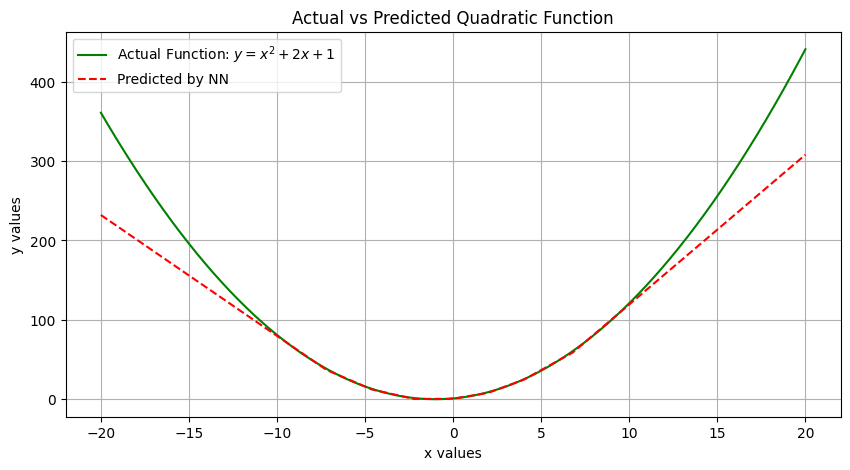

In [8]:
# First Plot: x vs predicted y values
plt.figure(figsize=(10, 5))

# Forward pass for plotting
x_plot = np.linspace(-20, 20, 1000)
z1_plot = np.dot(x_plot.reshape(-1, 1), w1) + b1  # Hidden layer
h1_plot = relu(z1_plot)                           # Apply ReLU
z2_plot = np.dot(h1_plot, w2) + b2                # Output layer

# Plot actual vs predicted
plt.plot(x_plot, target_function(x_plot), label='Actual Function: $y = x^2 + 2x + 1$', color='green')
plt.plot(x_plot, z2_plot, label='Predicted by NN', linestyle='--', color='red')
plt.title('Actual vs Predicted Quadratic Function')
plt.xlabel('x values')
plt.ylabel('y values')
plt.legend()
plt.grid(True)

# Display inline in the notebook
plt.show()

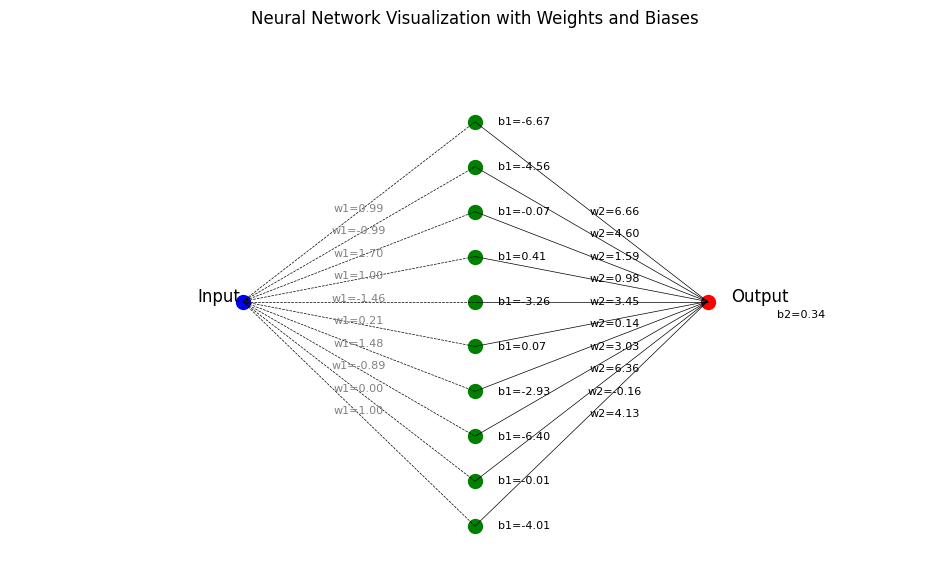

In [9]:
# Second Plot: Network structure visualization with one hidden layer
fig, ax = plt.subplots(figsize=(12, 7))
ax.set_xlim(-1, 3)
ax.set_ylim(-1, hidden_size + 1)

# Input layer (1 neuron)
ax.text(-0.1, hidden_size // 2, 'Input', fontsize=12, ha='center')
ax.plot(0, hidden_size // 2, 'bo', markersize=10)  # Input neuron

# Hidden layer neurons
for i in range(hidden_size):
    # Plot the hidden layer neurons
    ax.plot(1, i, 'go', markersize=10)  # Hidden layer neurons

    # Connect input to hidden with labeled weights (w1 and b1 on left)
    ax.plot([0, 1], [hidden_size // 2, i], 'k--', lw=0.5)
    ax.text(0.5, (hidden_size // 2 + i) / 2, f'w1={w1[0, i]:.2f}',
            fontsize=8, color='gray', ha='center')

    # Label the hidden neuron with b1 value directly next to the neuron
    ax.text(1.1, i, f'b1={b1[i]:.2f}', fontsize=8, ha='left', va='center')

# Output layer (1 neuron)
ax.plot(2, hidden_size // 2, 'ro', markersize=10)  # Output neuron
ax.text(2.1, hidden_size // 2, 'Output', fontsize=12, ha='left')

# Connect hidden to output with labeled weights (w2 and b2 on right)
for i in range(hidden_size):
    ax.plot([1, 2], [i, hidden_size // 2], 'k-', lw=0.5)
    ax.text(1.6, (i + hidden_size // 2) / 2, f'w2={w2[i, 0]:.2f}',
            fontsize=8, ha='center', va='center')

# Label the output neuron bias (b2)
ax.text(2.3, (hidden_size // 2) - 0.3, f'b2={b2[0]:.2f}',
        fontsize=8, ha='left', va='center')

# Title and display inline
ax.set_title('Neural Network Visualization with Weights and Biases')
ax.axis('off')
plt.show()

y = ReLU(x \cdot w1 + b1) \cdot w2 + b2 = max(0, x \times w1 + b1) \times w2 + b2

x \cdot w1 is a scalar \times a vector = a vector, + b1, a vector = a vector

That vector \cdot w2, a vector = a scalar.  That scalar plus b2, a scalar = a scalar

In [12]:
# ---------- Explicit ReLU equation (term-by-term) ----------
relu_terms = []
for i in range(hidden_size):
    relu_terms.append(f"({w2[i,0]:.6g} * max(0, {w1[0,i]:.6g} * x + {b1[i]:.6g}))")
relu_equation = " + ".join(relu_terms) + f" + {b2[0]:.6g}"

print("Neural network learned function (explicit ReLU form):")
print(f"y_hat(x) = {relu_equation}\n")

Neural network learned function (explicit ReLU form):
y_hat(x) = (4.12622 * max(0, 0.997957 * x + -4.01486)) + (-0.160824 * max(0, 0.000839596 * x + -0.0104932)) + (6.36255 * max(0, -0.889602 * x + -6.39509)) + (3.02823 * max(0, 1.47985 * x + -2.92503)) + (0.143985 * max(0, 0.205731 * x + 0.0719653)) + (3.45107 * max(0, -1.45971 * x + -3.26492)) + (0.981849 * max(0, 0.99568 * x + 0.414357)) + (1.58554 * max(0, 1.69904 * x + -0.0737215)) + (4.59968 * max(0, -0.986526 * x + -4.56335)) + (6.66443 * max(0, 0.985326 * x + -6.67318)) + 0.343177



ReLU provides a clipping function = max(0, z)

In [15]:
# --- Interactive prediction ---
while True:
    try:
        user_in = input("Enter an x value (or 'q' to quit): ")
        if user_in.lower() == 'q':
            break
        x_val = float(user_in)

        # Forward pass with the trained network
        z1_val = np.dot([[x_val]], w1) + b1
        h1_val = relu(z1_val)
        y_pred = np.dot(h1_val, w2) + b2

        y_true = target_function(x_val)

        print(f"x = {x_val:.2f}")
        print(f" Predicted y = {y_pred[0,0]:.4f}")
        print(f" Actual y    = {y_true:.4f}\n")

    except Exception as e:
        print("Invalid input, please enter a number or 'q' to quit.")

Enter an x value (or 'q' to quit): 10
x = 10.00
 Predicted y = 119.4154
 Actual y    = 121.0000

Enter an x value (or 'q' to quit): -1
x = -1.00
 Predicted y = 0.3432
 Actual y    = 0.0000

Enter an x value (or 'q' to quit): -10
x = -10.00
 Predicted y = 79.7508
 Actual y    = 81.0000

Enter an x value (or 'q' to quit): q


Here, we repeat the same math, but substitute the max function for ReLU.  Are the results the same?

In [14]:
# Interactive prediction: plug into the equation and compare
def nn_explicit(x):
    total = 0.0
    for i in range(hidden_size):
        total += w2[i,0] * max(0, w1[0,i] * x + b1[i])
    total += b2[0]
    return total

while True:
    user_in = input("Enter an x value (or 'q' to quit): ")
    if user_in.lower() == 'q':
        break
    try:
        x_val = float(user_in)
        y_pred = nn_explicit(x_val)
        y_true = target_function(x_val)
        print(f"x = {x_val:.2f}")
        print(f" Predicted y_hat(x) = {y_pred:.4f}")
        print(f" Actual    y(x)     = {y_true:.4f}\n")
    except ValueError:
        print("Please enter a valid number or 'q'.")

Enter an x value (or 'q' to quit): 10
x = 10.00
 Predicted y_hat(x) = 119.4154
 Actual    y(x)     = 121.0000

Enter an x value (or 'q' to quit): -10
x = -10.00
 Predicted y_hat(x) = 79.7508
 Actual    y(x)     = 81.0000

Enter an x value (or 'q' to quit): q


Notice what happens when we drop the ReLU component and just use the linear components!  The function simplifes to a linear function - but our input is non-linear!  Using a non-linear function (even a piecewise one) like ReLU allow us to introduce non-linearity into the model.

In [13]:
# ---------- Linear collapse (drop ReLU) ----------
# Expanded (term-by-term) form:
lin_terms = []
for i in range(hidden_size):
    lin_terms.append(f"({w2[i,0]:.6g} * ({w1[0,i]:.6g} * x + {b1[i]:.6g}))")
lin_equation_expanded = " + ".join(lin_terms) + f" + {b2[0]:.6g}"

# Simplified affine form: y_tilde(x) = a*x + c
a = float(np.sum(w2.ravel() * w1.ravel()))                    # Σ_i (w2_i * w1_i)
c = float(np.sum(w2.ravel() * b1.ravel()) + b2.ravel()[0])    # Σ_i (w2_i * b1_i) + b2

def format_affine(a, c):
    # Pretty "a*x + c" with correct sign spacing
    a_str = f"{a:.6g}"
    c_str = f"{abs(c):.6g}"
    sign = "+" if c >= 0 else "-"
    return f"{a_str} * x {sign} {c_str}"

print("Linear collapse (drop ReLU) — expanded form:")
print(f"y_tilde(x) = {lin_equation_expanded}")

print("\nLinear collapse (simplified affine):")
print(f"y_tilde(x) = {format_affine(a, c)}\n")

Linear collapse (drop ReLU) — expanded form:
y_tilde(x) = (4.12622 * (0.997957 * x + -4.01486)) + (-0.160824 * (0.000839596 * x + -0.0104932)) + (6.36255 * (-0.889602 * x + -6.39509)) + (3.02823 * (1.47985 * x + -2.92503)) + (0.143985 * (0.205731 * x + 0.0719653)) + (3.45107 * (-1.45971 * x + -3.26492)) + (0.981849 * (0.99568 * x + 0.414357)) + (1.58554 * (1.69904 * x + -0.0737215)) + (4.59968 * (-0.986526 * x + -4.56335)) + (6.66443 * (0.985326 * x + -6.67318)) + 0.343177

Linear collapse (simplified affine):
y_tilde(x) = 3.63132 * x - 142.198



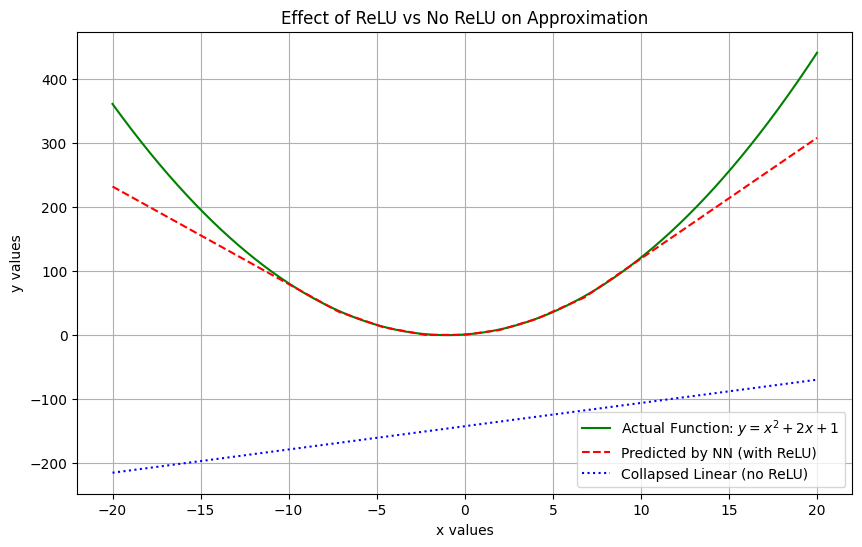

In [17]:
def nn_explicit_relu(x_vals):
    """Evaluate NN with ReLU on scalar or array x_vals."""
    x_vals = np.atleast_1d(x_vals)               # ensure array
    z1 = x_vals.reshape(-1, 1) @ w1 + b1         # (N, hidden_size)
    h1 = np.maximum(0, z1)                       # apply ReLU
    y  = h1 @ w2 + b2                            # (N, 1)
    return y.ravel()

def nn_linear_collapse(x_vals):
    """Evaluate linear collapse (drop ReLU)."""
    x_vals = np.atleast_1d(x_vals)
    a = float(np.sum(w2.ravel() * w1.ravel()))
    c = float(np.sum(w2.ravel() * b1.ravel()) + b2.ravel()[0])
    return a * x_vals + c

# Build grid for plotting
x_plot = np.linspace(-20, 20, 1000)
y_true = target_function(x_plot)

# With ReLU (piecewise-linear curve)
y_relu = nn_explicit_relu(x_plot)

# Without ReLU (linear collapse)
y_lin = nn_linear_collapse(x_plot)

plt.figure(figsize=(10, 6))
plt.plot(x_plot, y_true, label="Actual Function: $y=x^2+2x+1$", color="green")
plt.plot(x_plot, y_relu, "--", label="Predicted by NN (with ReLU)", color="red")
plt.plot(x_plot, y_lin, ":", label="Collapsed Linear (no ReLU)", color="blue")

plt.title("Effect of ReLU vs No ReLU on Approximation")
plt.xlabel("x values")
plt.ylabel("y values")
plt.legend()
plt.grid(True)
plt.show()
